# 05. Regressão Linear Simples

## 1. Visão geral

A regressão linear simples é um dos modelos mais importantes da estatística e da ciência de dados.  
Seu objetivo é modelar a relação entre uma variável explicativa \(X\) e uma variável resposta \(Y\) por meio de uma reta.

Neste capítulo, utilizaremos uma base com **temperatura** e **vendas de sorvetes** para responder à seguinte pergunta:

> Existe uma relação linear entre temperatura e vendas de sorvetes?  
> Se sim, quão bem uma reta consegue explicar e prever esse comportamento?

Além da aplicação prática em Python, este notebook dá atenção especial à interpretação matemática do modelo e à avaliação de performance.

## 2. Formulação matemática do modelo

Na regressão linear simples, assumimos que a variável resposta pode ser escrita como:

$$
Y_i = \beta_0 + \beta_1 X_i + \varepsilon_i
$$

Onde:

- $Y_i$: valor observado da variável resposta  
- $X_i$: valor observado da variável explicativa  
- $\beta_0$: intercepto da reta  
- $\beta_1$: inclinação da reta  
- $\varepsilon_i$: erro aleatório (ou resíduo teórico)

### Interpretação dos coeficientes

- **$\beta_0$** indica o valor esperado de $Y$ quando $X = 0$  
- **$\beta_1$** indica a variação média esperada em $Y$ para cada aumento de 1 unidade em $X$

Neste exemplo:

- $X$ = temperatura  
- $Y$ = vendas de sorvetes  

Se $\beta_1 > 0$, então temperaturas maiores tendem a aumentar as vendas.

## 3. Como o modelo é ajustado?

A regressão linear simples ajusta a reta que **minimiza a soma dos quadrados dos resíduos**.  
Esse procedimento é conhecido como **Método dos Mínimos Quadrados Ordinários (OLS — Ordinary Least Squares)**.

### Função objetivo

$$
\min \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Como $\hat{y}_i = \beta_0 + \beta_1 x_i$, o modelo busca os coeficientes $\beta_0$ e $\beta_1$ que minimizam:

$$
\min \sum_{i=1}^{n}(y_i - (\beta_0 + \beta_1 x_i))^2
$$

### Por que elevar ao quadrado?

Elevamos os resíduos ao quadrado porque isso:

- penaliza mais fortemente erros grandes  
- evita cancelamento entre erros positivos e negativos  
- produz uma função suave, conveniente para otimização  

Esse é o fundamento matemático do ajuste da reta de regressão.

In [1]:
# CÉLULA 1 — IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

np.random.seed(42)

In [2]:
# Leitura do arquivo
import pandas as pd
dados = pd.read_excel("Sorvete.xlsx")

dados.head()

,Temperatura,Vendas_Sorvetes
0,26,268.125258
1,39,403.562400
2,34,339.279899
3,30,310.035329
4,27,273.616360


## 4. Conhecendo a base

Antes de construir qualquer modelo, precisamos entender quais são as variáveis disponíveis e qual será o papel de cada uma:

- **Temperatura** → variável explicativa (\(X\))
- **Vendas_Sorvetes** → variável resposta (\(Y\))

A pergunta central é se a temperatura ajuda a explicar a variação observada nas vendas.

In [3]:
# CÉLULA 3 — VISÃO GERAL DA BASE

dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperatura      100 non-null    int64  
 1   Vendas_Sorvetes  100 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [4]:
# CÉLULA 4 — ESTATÍSTICAS DESCRITIVAS

dados.describe()

,Temperatura,Vendas_Sorvetes
count,100.000000,100.000000
mean,29.010000,290.258069
std,5.535003,56.538228
min,20.000000,183.925168
25%,24.750000,242.430217
50%,28.500000,283.326697
75%,34.000000,337.181324
max,39.000000,403.562400


## 5. Relação entre as variáveis

Um primeiro passo importante é verificar visualmente se existe um padrão aproximadamente linear entre temperatura e vendas.

Se os pontos tenderem a se organizar em torno de uma reta crescente ou decrescente, a regressão linear simples passa a ser uma candidata plausível.

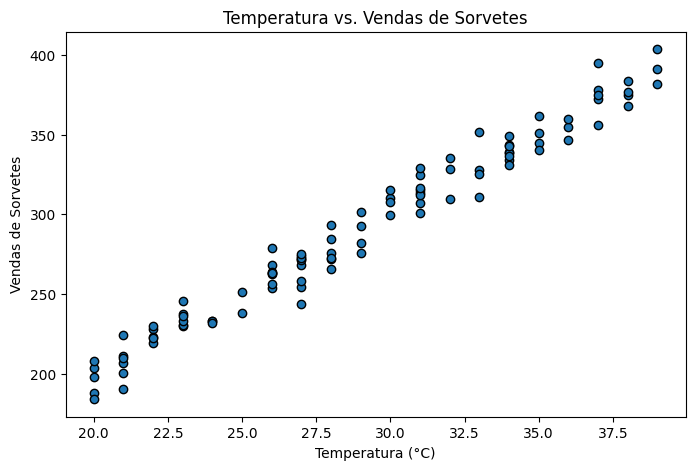

In [5]:
# CÉLULA 5 — SCATTER PLOT

plt.figure(figsize=(8, 5))
plt.scatter(dados["Temperatura"], dados["Vendas_Sorvetes"], edgecolor="black")

plt.title("Temperatura vs. Vendas de Sorvetes")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Vendas de Sorvetes")
plt.show()

> **Interpretação:**  
> O gráfico de dispersão sugere uma relação linear positiva entre temperatura e vendas de sorvetes. À medida que a temperatura aumenta, as vendas tendem a aumentar também, o que indica que um modelo linear pode ser adequado como primeira aproximação.

## 6. Correlação linear

A correlação de Pearson mede a **força e a direção da relação linear** entre duas variáveis.

$$
r = \frac{\text{cov}(X,Y)}{\sigma_X \sigma_Y}
$$

Onde:

- $r \approx 1$: forte correlação linear positiva  
- $r \approx -1$: forte correlação linear negativa  
- $r \approx 0$: ausência de relação linear forte  

É importante lembrar:

> Correlação não implica causalidade.

Mesmo assim, uma correlação alta costuma ser um bom sinal inicial para regressão linear simples.

In [6]:
# CÉLULA 6 — MATRIZ DE CORRELAÇÃO

dados[["Temperatura", "Vendas_Sorvetes"]].corr()

,Temperatura,Vendas_Sorvetes
Temperatura,1.000000,0.985589
Vendas_Sorvetes,0.985589,1.000000


> **Interpretação:**  
> O coeficiente de correlação mede o grau de associação linear entre temperatura e vendas. Um valor alto e positivo indica que, nesta base, dias mais quentes estão fortemente associados a maiores vendas de sorvetes.

## 7. Separando treino e teste

Em aprendizado de máquina supervisionado, separamos os dados em:

- **treino**: usado para ajustar o modelo
- **teste**: usado para avaliar generalização

Essa separação ajuda a verificar se o modelo aprende uma relação útil ou apenas memoriza o conjunto observado.

In [7]:
# CÉLULA 7 — DEFINIÇÃO DE X E y

X = dados[["Temperatura"]]
y = dados["Vendas_Sorvetes"]

In [8]:
# CÉLULA 8 — SPLIT TREINO / TESTE

from sklearn.model_selection import train_test_split

# Divide os dados em treino (80%) e teste (20%)
# X → variável explicativa (features)
# y → variável alvo (target)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   # proporção do conjunto de teste (20%)
    random_state=42  # fixa a aleatoriedade para reprodutibilidade
)

# Exibe as dimensões dos conjuntos gerados
# (linhas, colunas) para X | (linhas,) para y
print("Shape de X_train:", X_train.shape)  # dados usados para treinar o modelo
print("Shape de X_test:", X_test.shape)    # dados usados para avaliar o modelo
print("Shape de y_train:", y_train.shape)  # valores reais de treino
print("Shape de y_test:", y_test.shape)    # valores reais de teste

Shape de X_train: (80, 1)
Shape de X_test: (20, 1)
Shape de y_train: (80,)
Shape de y_test: (20,)


## 8. Treinando o modelo

Agora ajustaremos a regressão linear simples usando a classe `LinearRegression` do scikit-learn.

Ela estima automaticamente os coeficientes $\beta_0$ e $\beta_1$ pelo método dos mínimos quadrados.

In [9]:
# CÉLULA 9 — TREINAMENTO DO MODELO

from sklearn.linear_model import LinearRegression

# Instancia o modelo de regressão linear
# Por padrão, ajusta intercepto (β0) e coeficiente(s) (β1, ..., βn)
modelo = LinearRegression()

# Treina o modelo utilizando os dados de treino
# O algoritmo estima os parâmetros que minimizam o erro quadrático (MQO)
# X_train → variáveis explicativas
# y_train → variável alvo
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# CÉLULA 10 — COEFICIENTES DO MODELO

intercepto = modelo.intercept_
coeficiente = modelo.coef_[0]

print(f"Intercepto (beta_0): {intercepto:.4f}")
print(f"Inclinação (beta_1): {coeficiente:.4f}")
print(f"Equação estimada: y = {intercepto:.4f} + {coeficiente:.4f} * x")

Intercepto (beta_0): -2.5958
Inclinação (beta_1): 10.1088
Equação estimada: y = -2.5958 + 10.1088 * x


> **Interpretação:**  
> O intercepto representa o valor previsto de vendas quando a temperatura é igual a zero. Já a inclinação indica quanto, em média, as vendas variam para cada aumento de 1 grau na temperatura. Como o coeficiente angular é positivo, o modelo sugere que temperaturas maiores estão associadas a maiores vendas.

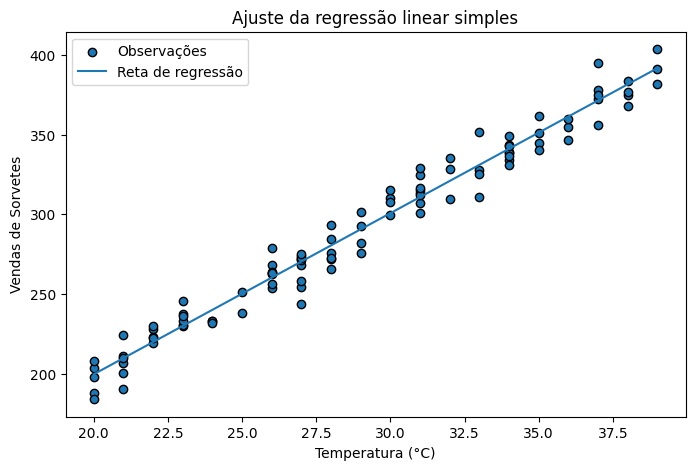

In [11]:
# CÉLULA 11 — RETA AJUSTADA SOBRE OS DADOS

plt.figure(figsize=(8, 5))
plt.scatter(dados["Temperatura"], dados["Vendas_Sorvetes"], label="Observações", edgecolor="black")

x_linha = np.linspace(dados["Temperatura"].min(), dados["Temperatura"].max(), 100)
y_linha = intercepto + coeficiente * x_linha

plt.plot(x_linha, y_linha, label="Reta de regressão")

plt.title("Ajuste da regressão linear simples")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Vendas de Sorvetes")
plt.legend()
plt.show()

> **Interpretação:**  
> A reta ajustada resume a tendência média entre temperatura e vendas. Quanto mais próximos os pontos estiverem da reta, menor tende a ser o erro do modelo. Neste caso, a reta acompanha bem o padrão crescente observado nos dados.

## 9. Previsões e resíduos

Após o treinamento, o modelo produz previsões $\hat{y}$ para novos valores de $X$.

O **resíduo** é definido como:

$$
e_i = y_i - \hat{y}_i
$$

Ele representa o erro observado em cada previsão.

### Leitura dos resíduos

- resíduo positivo → o valor real ficou acima do previsto  
- resíduo negativo → o valor real ficou abaixo do previsto  
- resíduos próximos de zero → boa aproximação local  

In [12]:
# CÉLULA 12 — PREVISÕES NO CONJUNTO DE TESTE

previsoes = modelo.predict(X_test)

resultado_previsoes = pd.DataFrame({
    "Temperatura": X_test["Temperatura"].values,
    "Real": y_test.values,
    "Previsto": previsoes
})

resultado_previsoes.head()

,Temperatura,Real,Previsto
0,36,346.795434,361.321566
1,25,238.313220,250.124604
2,34,330.805758,341.103936
3,22,219.255541,219.798160
4,34,342.575504,341.103936


In [13]:
# CÉLULA 13 — CÁLCULO DOS RESÍDUOS

residuos = y_test - previsoes

resultado_previsoes["Residuo"] = residuos.values
resultado_previsoes.head()

,Temperatura,Real,Previsto,Residuo
0,36,346.795434,361.321566,-14.526132
1,25,238.313220,250.124604,-11.811385
2,34,330.805758,341.103936,-10.298179
3,22,219.255541,219.798160,-0.542620
4,34,342.575504,341.103936,1.471568


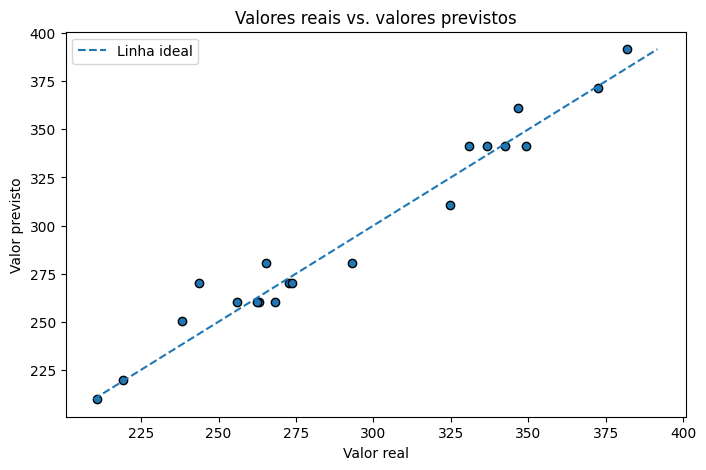

In [14]:
# CÉLULA 14 — REAL VS PREVISTO

plt.figure(figsize=(8, 5))
plt.scatter(y_test, previsoes, edgecolor="black")

lim_min = min(y_test.min(), previsoes.min())
lim_max = max(y_test.max(), previsoes.max())

plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--", label="Linha ideal")

plt.title("Valores reais vs. valores previstos")
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.legend()
plt.show()

> **Interpretação:**  
> Quanto mais próximos os pontos estiverem da linha ideal de 45 graus, mais próximas as previsões estarão dos valores reais. A concentração dos pontos ao redor dessa diagonal indica boa capacidade preditiva do modelo no conjunto de teste.

## 10. Avaliação de performance do modelo

A avaliação de performance em regressão deve responder a duas perguntas:

1. **Quanto o modelo erra?**
2. **Quanto da variabilidade de $Y$ ele consegue explicar?**

As métricas mais usadas neste contexto são:

### 10.1 MSE — Mean Squared Error

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

É a média dos erros ao quadrado.  
Como os resíduos são elevados ao quadrado, erros grandes recebem penalização maior.

### 10.2 RMSE — Root Mean Squared Error

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

É a raiz quadrada do MSE.  
Seu grande benefício é que ele volta para a **mesma unidade da variável resposta**, o que facilita a interpretação prática.

### 10.3 MAE — Mean Absolute Error

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

Representa o erro absoluto médio.  
É uma métrica mais robusta do que o RMSE quando há poucos erros muito grandes.

### 10.4 R² — Coeficiente de determinação

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
$$

O $R^2$ compara o erro do modelo com o erro de um modelo ingênuo que sempre preveria a média $\bar{y}$.

#### Interpretação do R²

- $R^2 = 1$ → ajuste perfeito  
- $R^2 = 0$ → não melhora em relação à média  
- $R^2 < 0$ → pior que prever a média  

In [15]:
# CÉLULA 15 — MÉTRICAS DE PERFORMANCE

mse = mean_squared_error(y_test, previsoes)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, previsoes)
r2 = r2_score(y_test, previsoes)

metricas = pd.DataFrame({
    "metrica": ["MSE", "RMSE", "MAE", "R²"],
    "valor": [mse, rmse, mae, r2]
})

metricas

,metrica,valor
0,MSE,101.645250
1,RMSE,10.081927
2,MAE,7.680993
3,R²,0.959417


> **Interpretação:**  
> O MAE mostra, em média, o quanto as previsões se afastam dos valores reais em termos absolutos. O RMSE também mede erro, mas penaliza mais fortemente erros grandes. Já o R² indica quanto da variabilidade das vendas é explicada pela temperatura. Em conjunto, essas métricas mostram se o modelo é útil, preciso e coerente com o problema.

In [16]:
# CÉLULA 16 — EXIBIÇÃO FORMATADA DAS MÉTRICAS

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

MSE:  101.6452
RMSE: 10.0819
MAE:  7.6810
R²:   0.9594


## 11. Comparando MAE e RMSE

Uma leitura importante em regressão é comparar MAE e RMSE:

- Se **RMSE** estiver muito acima do **MAE**, isso sugere que existem erros grandes pesando mais no modelo.
- Se ambos estiverem próximos, os erros tendem a ser mais uniformes.

Essa comparação ajuda a entender a distribuição dos resíduos e a estabilidade da predição.

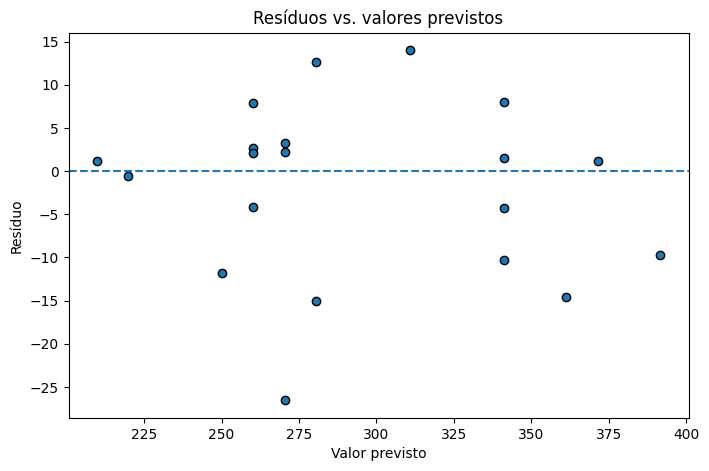

In [17]:
# CÉLULA 17 — RESÍDUOS VS VALORES PREVISTOS

plt.figure(figsize=(8, 5))
plt.scatter(previsoes, residuos, edgecolor="black")
plt.axhline(0, linestyle="--")

plt.title("Resíduos vs. valores previstos")
plt.xlabel("Valor previsto")
plt.ylabel("Resíduo")
plt.show()

> **Interpretação:**  
> O gráfico de resíduos ajuda a verificar se os erros do modelo estão distribuídos de forma aproximadamente aleatória ao redor de zero. Quando isso acontece, há indício de que a forma linear é razoável. Padrões sistemáticos podem indicar não linearidade, heterocedasticidade ou especificação inadequada do modelo.

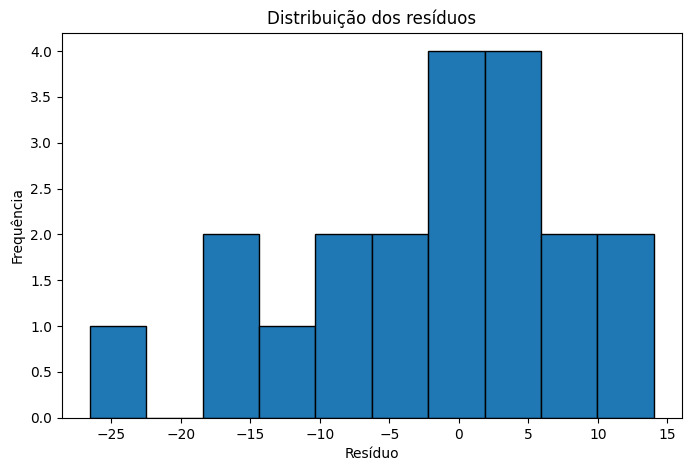

In [18]:
# CÉLULA 18 — HISTOGRAMA DOS RESÍDUOS

plt.figure(figsize=(8, 5))
plt.hist(residuos, bins=10, edgecolor="black")

plt.title("Distribuição dos resíduos")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.show()

> **Interpretação:**  
> O histograma dos resíduos permite verificar se os erros estão aproximadamente centrados em zero e se há simetria razoável. Embora a regressão para previsão não exija normalidade estrita dos resíduos, esse diagnóstico é útil para entender a qualidade do ajuste e a presença de possíveis desvios importantes.

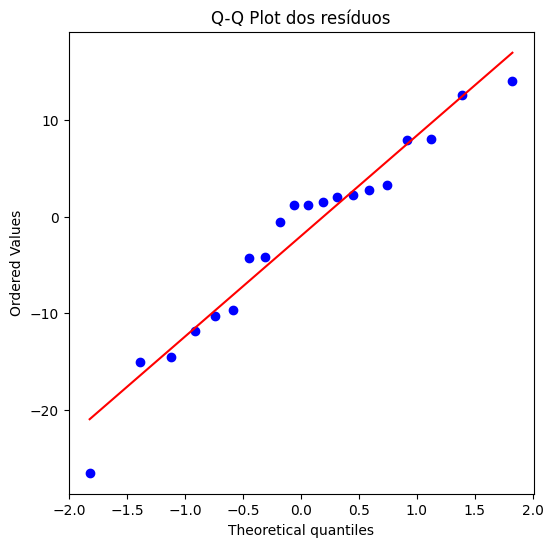

In [19]:
# CÉLULA 19 — Q-Q PLOT DOS RESÍDUOS

plt.figure(figsize=(6, 6))
stats.probplot(residuos, dist="norm", plot=plt)

plt.title("Q-Q Plot dos resíduos")
plt.show()

> **Interpretação:**  
> Se os resíduos seguirem aproximadamente a linha diagonal, isso sugere comportamento próximo da normalidade. Desvios fortes nas extremidades ou curvaturas acentuadas indicam que a distribuição dos resíduos se afasta da normal, o que pode ser relevante principalmente em contextos inferenciais.

## 12. Limitações e cuidados

Mesmo quando a regressão linear apresenta bom desempenho, alguns cuidados são importantes:

- **Correlação não implica causalidade**
- O bom ajuste depende da relação ser aproximadamente linear
- Outliers podem distorcer a reta
- Resíduos com padrão sistemático podem indicar que o modelo está mal especificado
- Um bom \(R^2\) não garante que o modelo seja causal ou universalmente válido

Em outras palavras:

> desempenho numérico bom não substitui análise crítica dos dados e do contexto.

## 13. Conclusão

A regressão linear simples oferece uma forma clara e interpretável de modelar a relação entre duas variáveis quantitativas.  
Neste exemplo, observamos que a temperatura apresenta forte associação positiva com as vendas de sorvetes, e que uma reta consegue capturar bem esse padrão.

Do ponto de vista matemático, o modelo é ajustado por mínimos quadrados, minimizando a soma dos resíduos ao quadrado.  
Do ponto de vista prático, sua qualidade pode ser avaliada por métricas como MAE, RMSE e R², além da análise visual dos resíduos.

Esse é um excelente ponto de partida para compreender modelos supervisionados mais avançados.

## 14. Referências bibliográficas

- James, G.; Witten, D.; Hastie, T.; Tibshirani, R. (2021). *An Introduction to Statistical Learning*. Springer.
- Montgomery, D. C.; Peck, E. A.; Vining, G. G. (2021). *Introduction to Linear Regression Analysis*. Wiley.
- Kutner, M. H.; Nachtsheim, C. J.; Neter, J.; Li, W. (2004). *Applied Linear Statistical Models*. McGraw-Hill.
- Draper, N. R.; Smith, H. (1998). *Applied Regression Analysis*. Wiley.